# Advanced Social Media Engagement Prediction
### Phase 1 : Project 9
---

## Task 1: Data Understanding and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Social_Media_Engagement_Dataset.csv')

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (12000, 28)

Data Types:
post_id                        str
timestamp                      str
day_of_week                    str
platform                       str
user_id                        str
location                       str
language                       str
text_content                   str
hashtags                       str
mentions                       str
keywords                       str
topic_category                 str
sentiment_score            float64
sentiment_label                str
emotion_type                   str
toxicity_score             float64
likes_count                  int64
shares_count                 int64
comments_count               int64
impressions                  int64
engagement_rate            float64
brand_name                     str
product_name                   str
campaign_name                  str
campaign_phase                 str
user_past_sentiment_avg    float64
user_engagement_growth     float64
buzz_change_rate       

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


In [2]:
# Missing values
print('Missing Values:')
print(df.isnull().sum())
print('\nMissing % :')
print((df.isnull().sum()/len(df)*100).round(2))

Missing Values:
post_id                       0
timestamp                     0
day_of_week                   0
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                   3941
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

Missing % :
post_id                     0.00
timestamp                   0

In [3]:
# Descriptive statistics
print('Descriptive Statistics:')
df.describe()

Descriptive Statistics:


,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


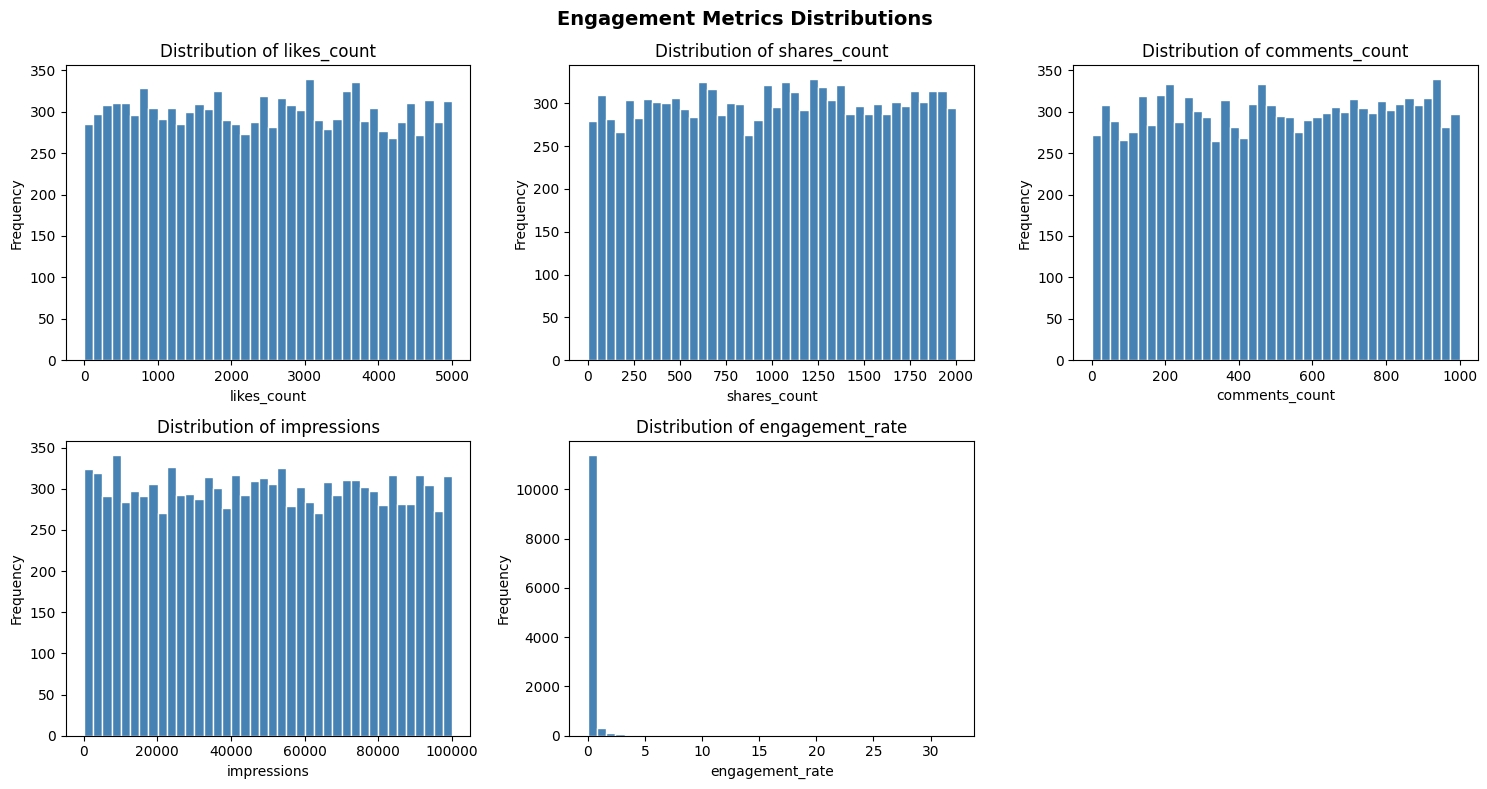

In [4]:
# Distribution of engagement metrics
engagement_cols = ['likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(engagement_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Engagement Metrics Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 2: Exploratory Data Analysis (EDA)

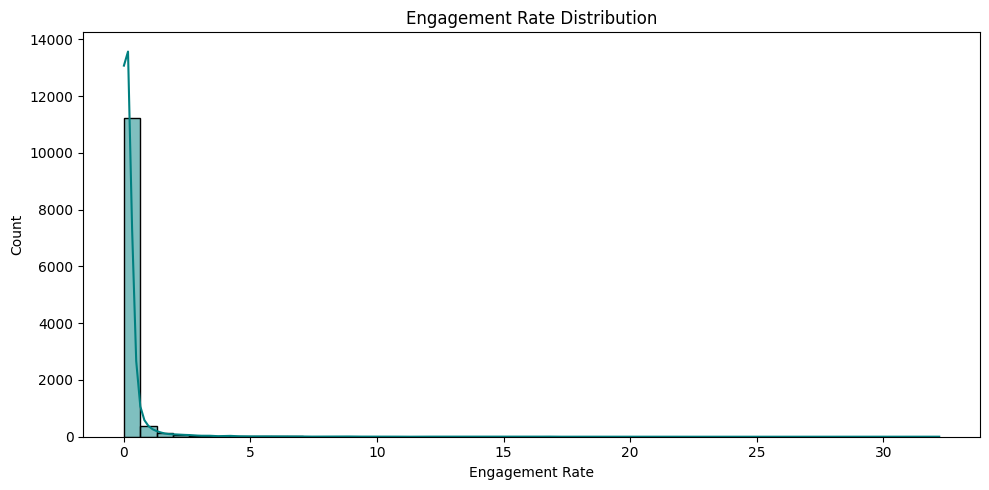

In [5]:
# Engagement rate distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['engagement_rate'].dropna(), bins=50, kde=True, color='teal')
plt.title('Engagement Rate Distribution')
plt.xlabel('Engagement Rate')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

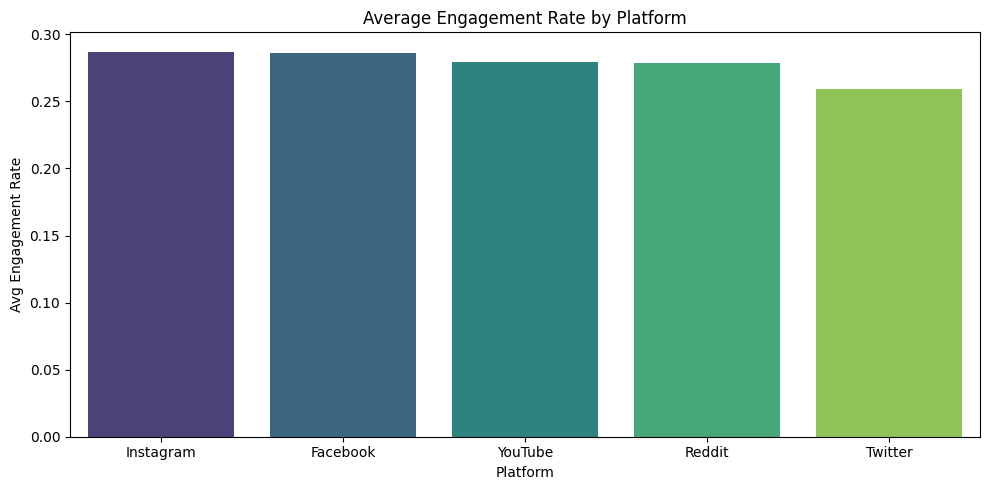

In [6]:
# Engagement vs Platform
plt.figure(figsize=(10, 5))
platform_eng = df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False)
sns.barplot(x=platform_eng.index, y=platform_eng.values, palette='viridis')
plt.title('Average Engagement Rate by Platform')
plt.xlabel('Platform')
plt.ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

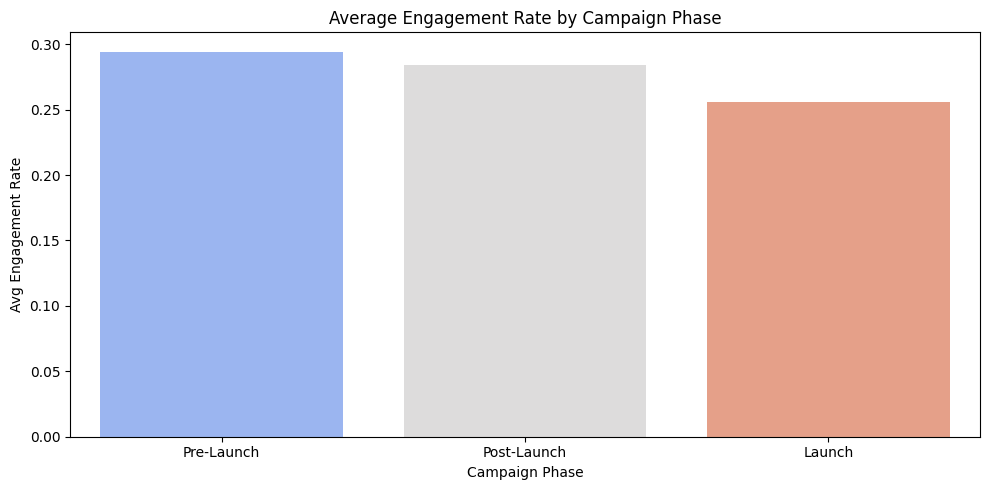

In [7]:
# Engagement vs Campaign Phase
plt.figure(figsize=(10, 5))
phase_eng = df.groupby('campaign_phase')['engagement_rate'].mean().sort_values(ascending=False)
sns.barplot(x=phase_eng.index, y=phase_eng.values, palette='coolwarm')
plt.title('Average Engagement Rate by Campaign Phase')
plt.xlabel('Campaign Phase')
plt.ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

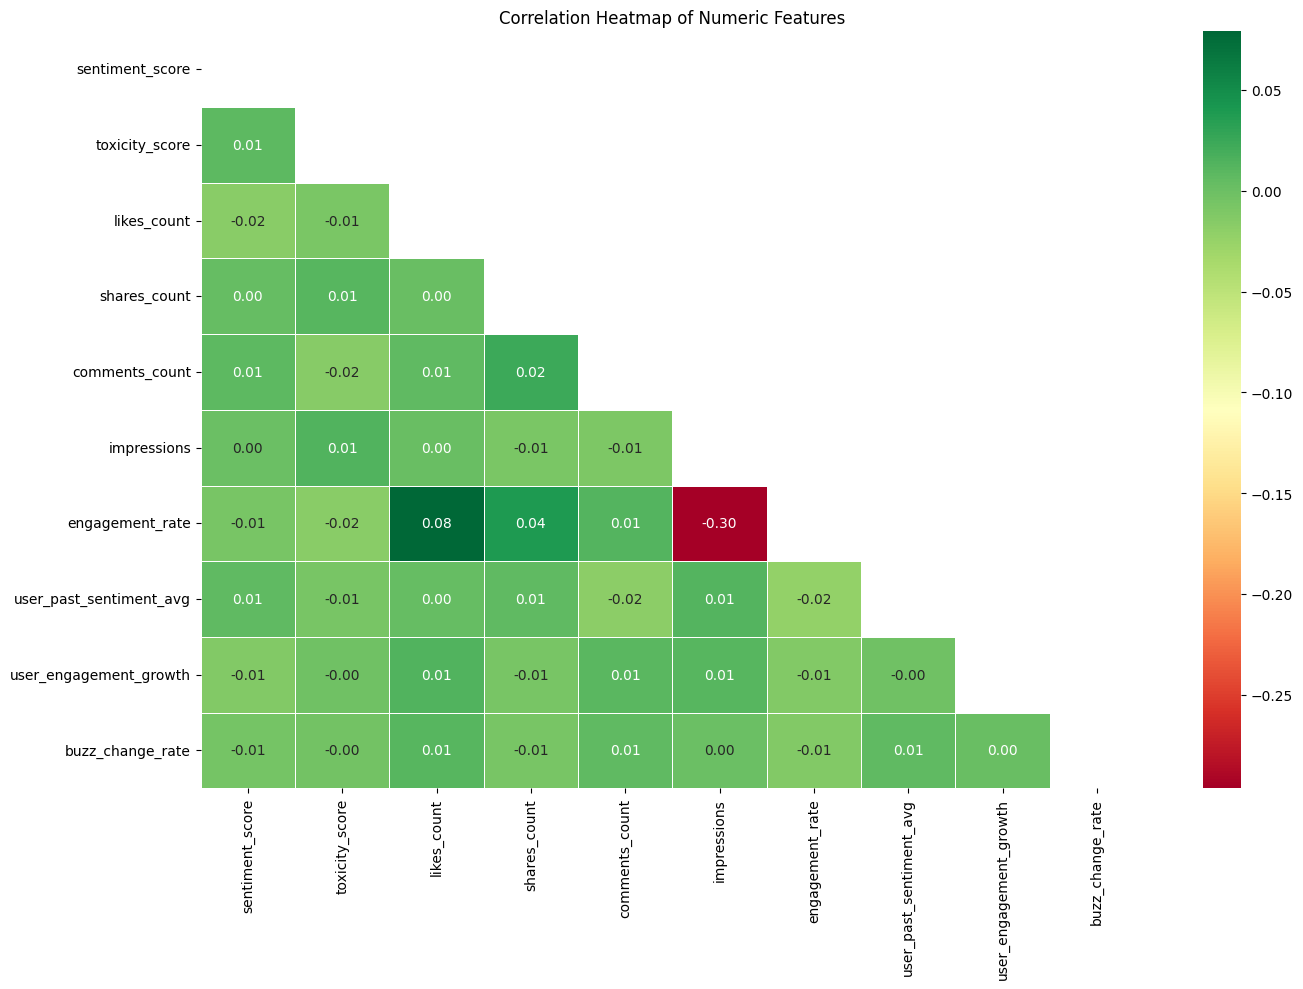

In [8]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

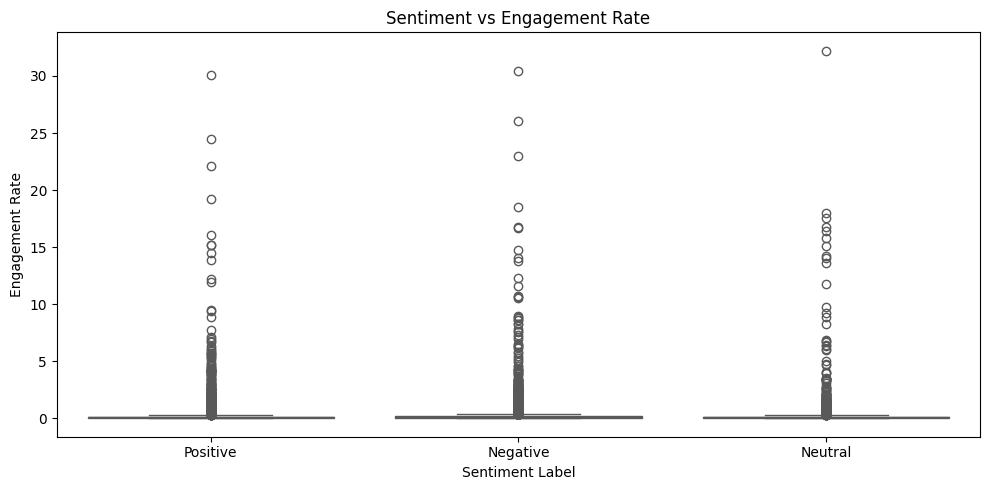

In [9]:
# Sentiment vs Engagement
plt.figure(figsize=(10, 5))
sns.boxplot(x='sentiment_label', y='engagement_rate', data=df, palette='Set2')
plt.title('Sentiment vs Engagement Rate')
plt.xlabel('Sentiment Label')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

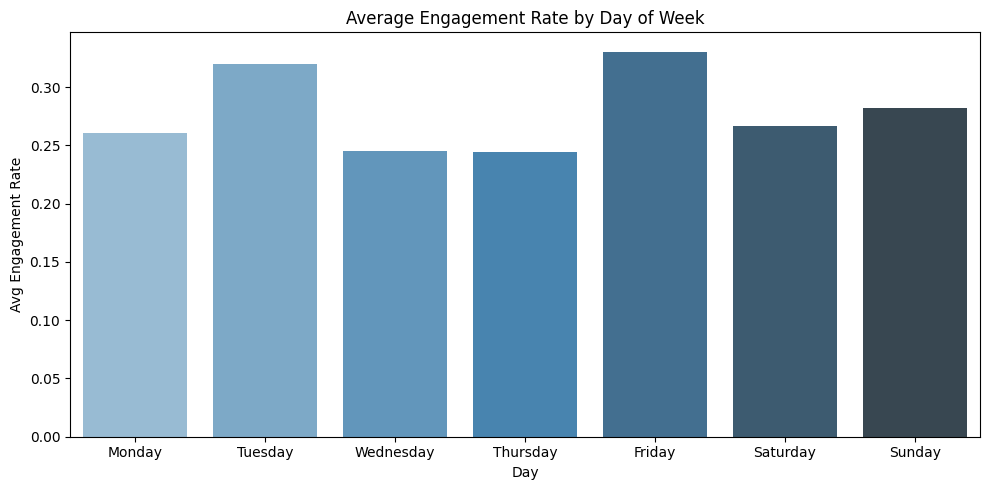

In [10]:
# Day of week vs engagement
plt.figure(figsize=(10, 5))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_eng = df.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)
sns.barplot(x=day_eng.index, y=day_eng.values, palette='Blues_d')
plt.title('Average Engagement Rate by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

## Task 3: Data Preprocessing

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_clean = df.copy()

# Handle missing values
for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('Missing values after cleaning:', df_clean.isnull().sum().sum())

Missing values after cleaning: 3941


In [12]:
# Outlier removal using IQR on engagement_rate
Q1 = df_clean['engagement_rate'].quantile(0.25)
Q3 = df_clean['engagement_rate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = len(df_clean)
df_clean = df_clean[(df_clean['engagement_rate'] >= lower) & (df_clean['engagement_rate'] <= upper)]
print(f'Removed {before - len(df_clean)} outliers. Remaining rows: {len(df_clean)}')

Removed 1494 outliers. Remaining rows: 10506


In [13]:
# Encode categorical variables
cat_cols = ['platform', 'day_of_week', 'language', 'sentiment_label', 
            'emotion_type', 'campaign_phase', 'topic_category']
le = LabelEncoder()
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))

print('Encoding complete.')

Encoding complete.


## Task 4: Feature Engineering

In [14]:
# Total engagement
df_clean['total_engagement'] = df_clean['likes_count'] + df_clean['shares_count'] + df_clean['comments_count']

# Timestamp features
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['month'] = df_clean['timestamp'].dt.month
df_clean['is_weekend'] = df_clean['timestamp'].dt.dayofweek.isin([5,6]).astype(int)

# Count hashtags and mentions
df_clean['hashtag_count'] = df_clean['hashtags'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() else 0)
df_clean['mention_count'] = df_clean['mentions'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() else 0)
df_clean['text_length'] = df_clean['text_content'].apply(lambda x: len(str(x)))

# Sentiment interaction
df_clean['sentiment_x_growth'] = df_clean['sentiment_score'] * df_clean['user_engagement_growth']

print('New features created:')
print(['total_engagement','hour','month','is_weekend','hashtag_count','mention_count','text_length','sentiment_x_growth'])

New features created:
['total_engagement', 'hour', 'month', 'is_weekend', 'hashtag_count', 'mention_count', 'text_length', 'sentiment_x_growth']


## Task 5: Machine Learning Models

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Create classification target: High (1) vs Low (0) engagement
df_clean['eng_label'] = (df_clean['engagement_rate'] > df_clean['engagement_rate'].median()).astype(int)

feature_cols = [
    'platform_enc','day_of_week_enc','sentiment_label_enc','emotion_type_enc',
    'campaign_phase_enc','topic_category_enc','sentiment_score','toxicity_score',
    'user_past_sentiment_avg','user_engagement_growth','buzz_change_rate',
    'hashtag_count','mention_count','text_length','hour','month','is_weekend',
    'sentiment_x_growth','likes_count','shares_count','comments_count','impressions'
]

X = df_clean[feature_cols].fillna(0)
y = df_clean['eng_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (8404, 22), Test size: (2102, 22)


In [16]:
models = {
    'Linear Regression (MSE)': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=500),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Linear Regression (MSE)':
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        results[name] = round(rmse, 4)
        print(f'{name}: RMSE = {rmse:.4f}')
    else:
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
        acc = accuracy_score(y_test, preds)
        results[name] = round(acc, 4)
        print(f'{name}: Accuracy = {acc:.4f}')

Linear Regression (MSE): RMSE = 0.2840
Logistic Regression: Accuracy = 0.9967


KNN: Accuracy = 0.8297
Decision Tree: Accuracy = 0.9410


Random Forest: Accuracy = 0.9600
Naive Bayes: Accuracy = 0.9101


SVM: Accuracy = 0.9738


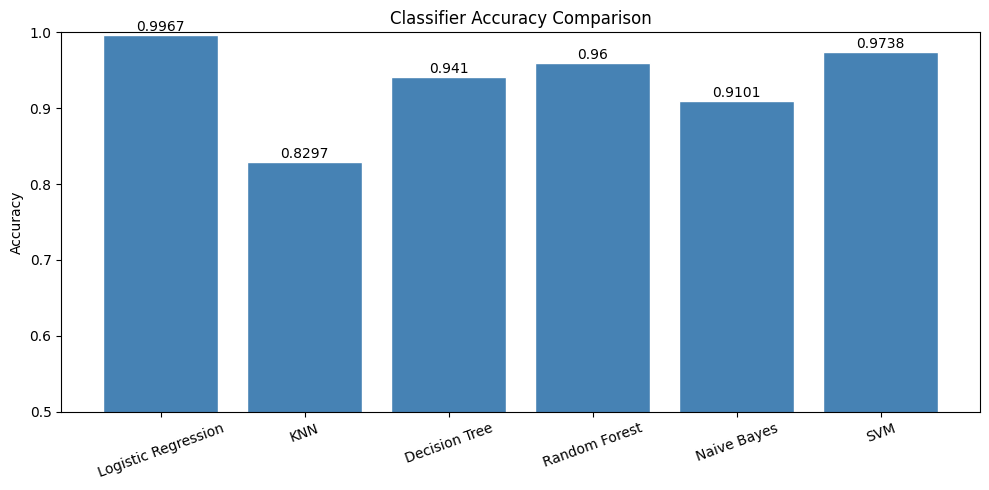

In [17]:
# Plot model comparison (excluding linear regression)
clf_results = {k: v for k, v in results.items() if k != 'Linear Regression (MSE)'}
plt.figure(figsize=(10, 5))
bars = plt.bar(clf_results.keys(), clf_results.values(), color='steelblue', edgecolor='white')
plt.ylim(0.5, 1.0)
plt.title('Classifier Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
for bar, val in zip(bars, clf_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Task 6: Ensemble and Advanced Models

In [18]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

ensemble_models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(iterations=200, random_state=42, verbose=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

ensemble_results = {}
for name, model in ensemble_models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    acc = accuracy_score(y_test, preds)
    ensemble_results[name] = round(acc, 4)
    print(f'{name}: Accuracy = {acc:.4f}')

Random Forest: Accuracy = 0.9605


XGBoost: Accuracy = 0.9781


CatBoost: Accuracy = 0.9862


Gradient Boosting: Accuracy = 0.9757


AdaBoost: Accuracy = 0.9776


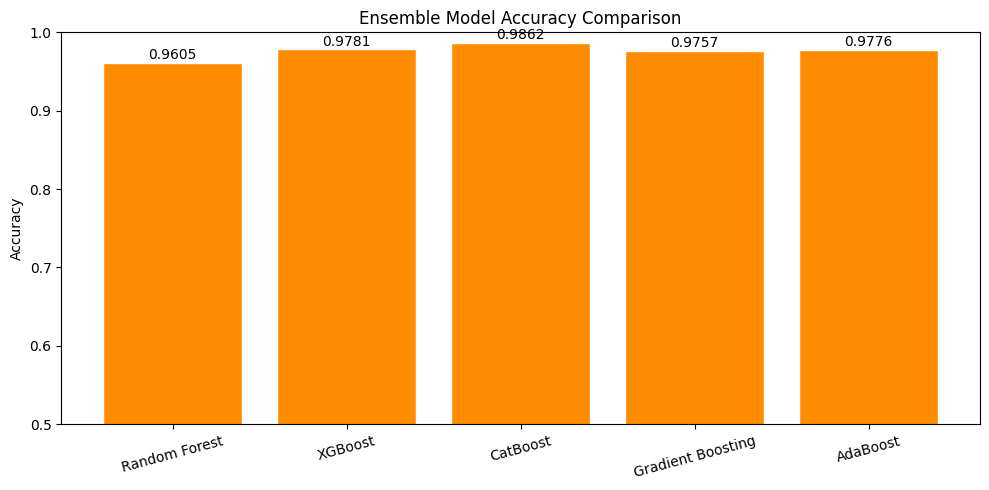

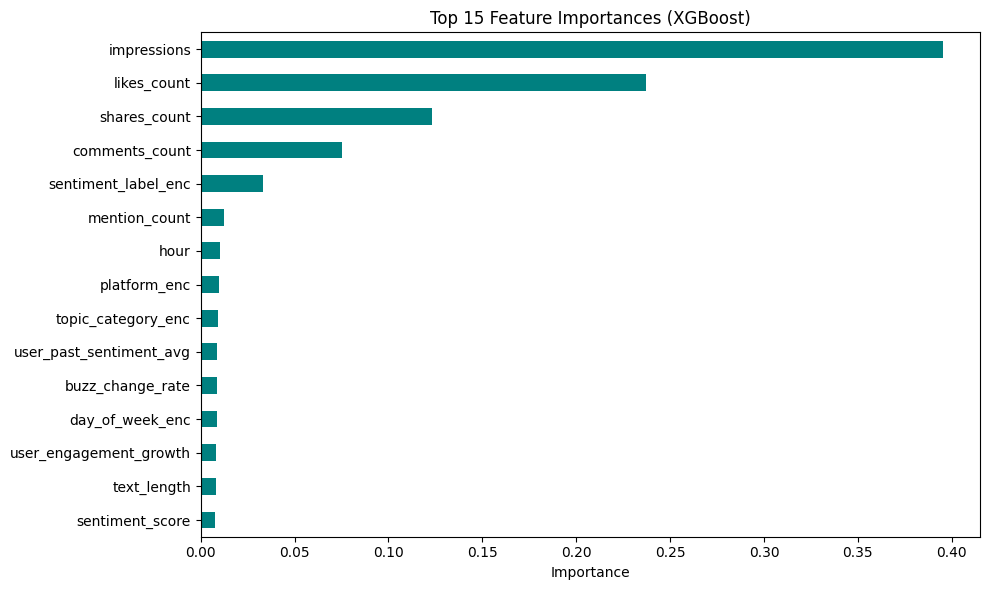

In [19]:
# Plot ensemble comparison
plt.figure(figsize=(10, 5))
bars = plt.bar(ensemble_results.keys(), ensemble_results.values(), color='darkorange', edgecolor='white')
plt.ylim(0.5, 1.0)
plt.title('Ensemble Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
for bar, val in zip(bars, ensemble_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Feature importance from XGBoost
xgb_model = ensemble_models['XGBoost']
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Task 7: Model Optimization

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline with scaler + Random Forest
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print('Best Params:', grid_search.best_params_)
print('Best CV Accuracy:', round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_model.predict(X_test))
print('Test Accuracy (Best Model):', round(test_acc, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best Params: {'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV Accuracy: 0.9566
Test Accuracy (Best Model): 0.961


Cross-Validation Scores: [0.9481 0.9595 0.9519 0.9638 0.9638]
Mean CV Accuracy: 0.9575
Std CV Accuracy: 0.0064


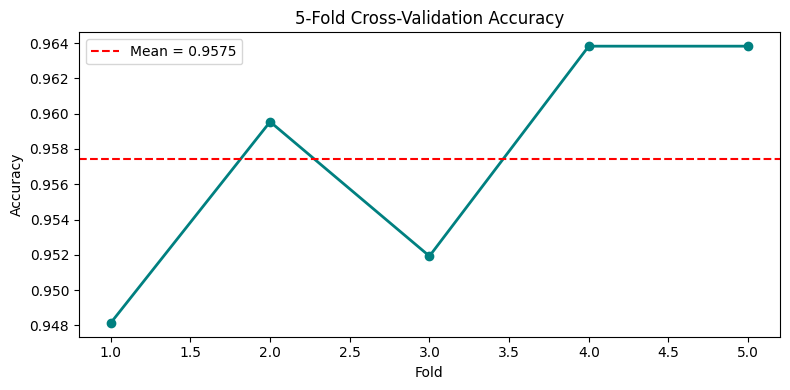

In [21]:
# Cross-validation scores
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print('Cross-Validation Scores:', cv_scores.round(4))
print('Mean CV Accuracy:', round(cv_scores.mean(), 4))
print('Std CV Accuracy:', round(cv_scores.std(), 4))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores, marker='o', color='teal', linewidth=2)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Classification Report:
                 precision    recall  f1-score   support

 Low Engagement       0.97      0.96      0.96      1077
High Engagement       0.96      0.96      0.96      1025

       accuracy                           0.96      2102
      macro avg       0.96      0.96      0.96      2102
   weighted avg       0.96      0.96      0.96      2102



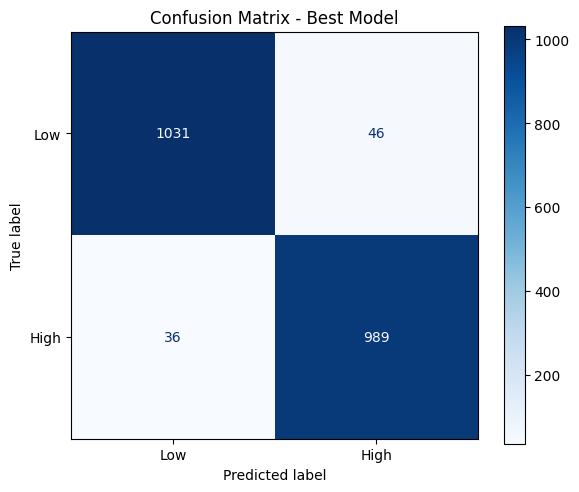

In [22]:
# Full classification report
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Low Engagement', 'High Engagement']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, 
    display_labels=['Low', 'High'], cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()

## Task 8: Unsupervised Learning - Clustering

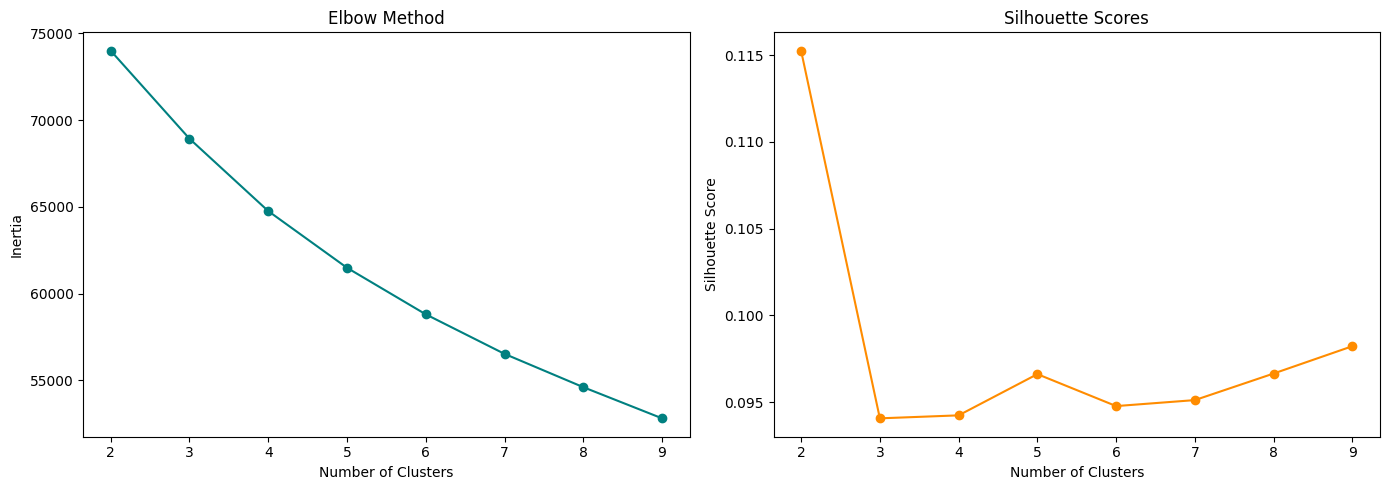

In [23]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

cluster_features = ['sentiment_score', 'toxicity_score', 'engagement_rate',
                    'likes_count', 'shares_count', 'comments_count',
                    'user_engagement_growth', 'buzz_change_rate']

X_cluster = df_clean[cluster_features].fillna(0)
X_cluster_sc = StandardScaler().fit_transform(X_cluster)

# Elbow Method for KMeans
inertias = []
sil_scores = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_sc)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_sc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', color='teal')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[1].plot(k_range, sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [24]:
# K-Means with best k
best_k = k_range[np.argmax(sil_scores)]
print(f'Best k: {best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_cluster_sc)

# Hierarchical Clustering
hier = AgglomerativeClustering(n_clusters=best_k)
df_clean['hier_cluster'] = hier.fit_predict(X_cluster_sc)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10)
df_clean['dbscan_cluster'] = dbscan.fit_predict(X_cluster_sc)
print(f'DBSCAN unique clusters: {df_clean["dbscan_cluster"].nunique()} (incl. noise=-1)')

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=best_k, random_state=42)
df_clean['gmm_cluster'] = gmm.fit_predict(X_cluster_sc)

print('All clustering methods applied.')

Best k: 2


DBSCAN unique clusters: 1 (incl. noise=-1)


All clustering methods applied.


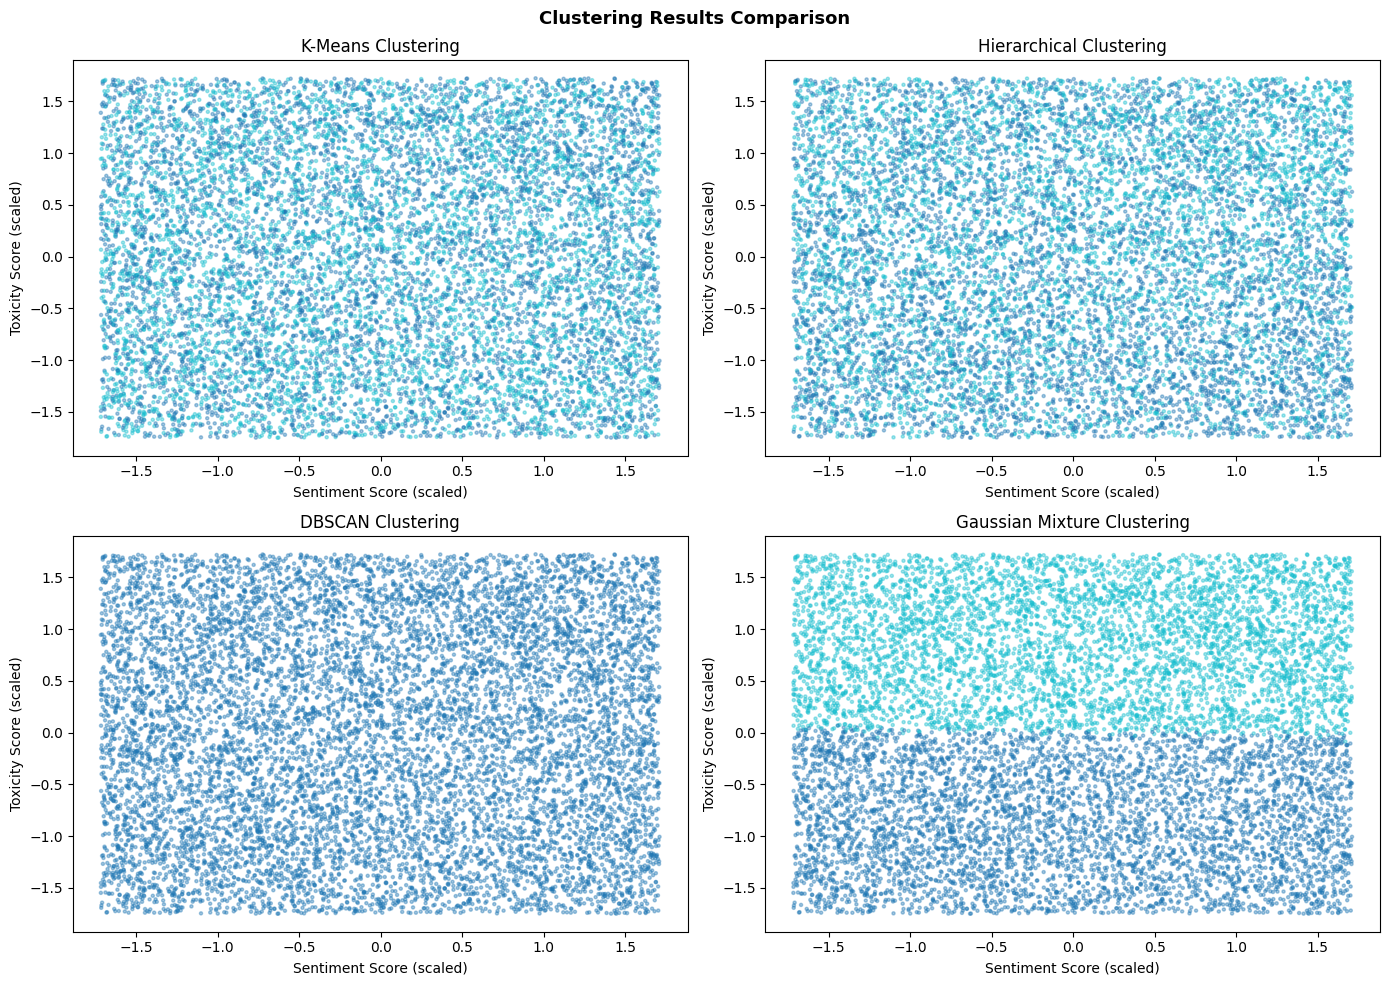

In [25]:
# Cluster visualization using first 2 features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cluster_methods = ['kmeans_cluster','hier_cluster','dbscan_cluster','gmm_cluster']
titles = ['K-Means','Hierarchical','DBSCAN','Gaussian Mixture']
for ax, method, title in zip(axes.flatten(), cluster_methods, titles):
    scatter = ax.scatter(X_cluster_sc[:, 0], X_cluster_sc[:, 1],
                         c=df_clean[method], cmap='tab10', alpha=0.4, s=5)
    ax.set_title(f'{title} Clustering')
    ax.set_xlabel('Sentiment Score (scaled)')
    ax.set_ylabel('Toxicity Score (scaled)')
plt.suptitle('Clustering Results Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 9: Dimensionality Reduction

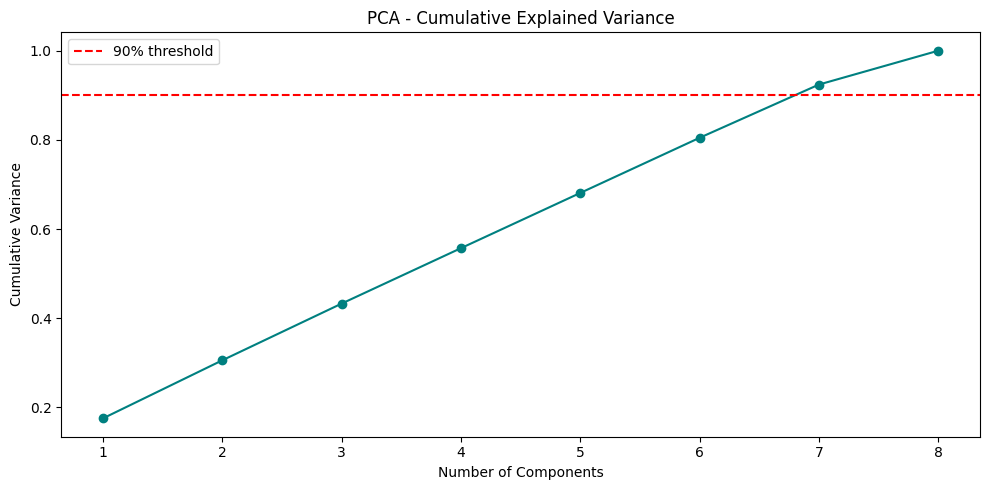

Explained variance per component: [0.175 0.13  0.127 0.124 0.124 0.124 0.119 0.076]


In [26]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# PCA
n_pca = min(8, X_cluster_sc.shape[1])
pca = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_cluster_sc)

plt.figure(figsize=(10, 5))
explained = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_pca+1), explained, marker='o', color='teal')
plt.axhline(0.9, color='red', linestyle='--', label='90% threshold')
plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.show()

print('Explained variance per component:', pca.explained_variance_ratio_.round(3))

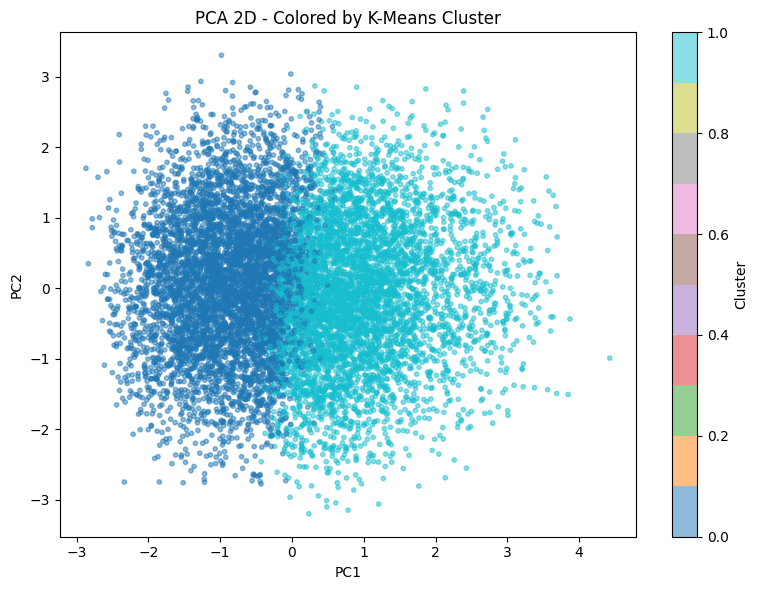

In [27]:
# PCA 2D visualization
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_cluster_sc)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=df_clean['kmeans_cluster'], cmap='tab10', alpha=0.5, s=10)
plt.title('PCA 2D - Colored by K-Means Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

In [28]:
# SVD
svd = TruncatedSVD(n_components=5, random_state=42)
X_svd = svd.fit_transform(X_cluster_sc)
print('SVD explained variance ratio:', svd.explained_variance_ratio_.round(3))

SVD explained variance ratio: [0.175 0.13  0.127 0.124 0.124]


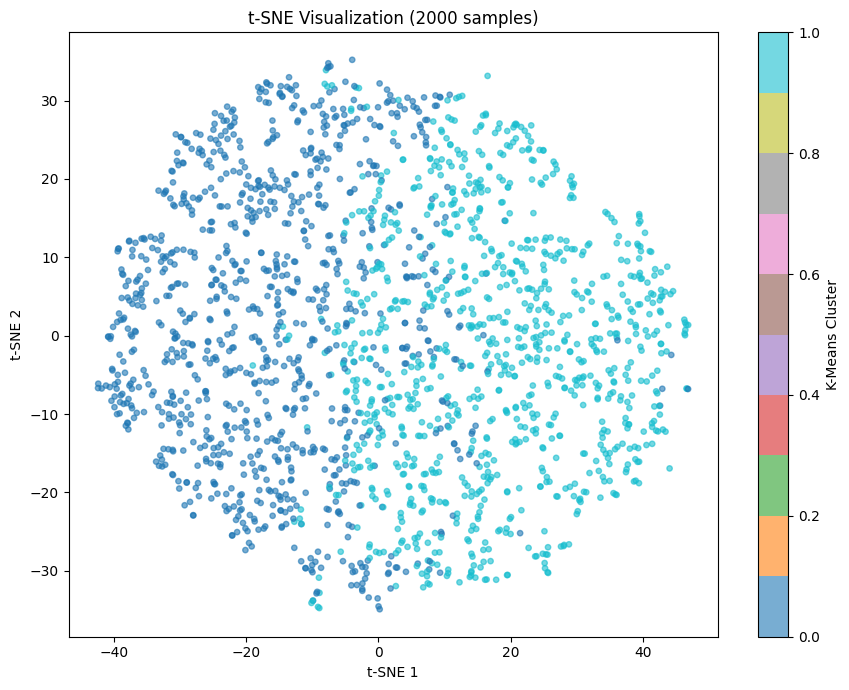

In [29]:
# t-SNE visualization (on a sample for speed)
sample_idx = np.random.choice(len(X_cluster_sc), 2000, replace=False)
X_tsne_input = X_cluster_sc[sample_idx]
labels_sample = df_clean['kmeans_cluster'].values[sample_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='K-Means Cluster')
plt.title('t-SNE Visualization (2000 samples)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## Task 10: Deep Learning Extension (Optional)

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)

# Prepare data
X_dl = scaler.fit_transform(X.fillna(0))
y_dl = y.values

X_tr, X_te, y_tr, y_te = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

# Build neural network
model_nn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_tr.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_nn.summary()

I0000 00:00:1773344971.629510     150 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773344971.645600     150 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773344971.709756     150 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773344977.042613     150 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773344977.083584     150 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


E0000 00:00:1773344978.621831     150 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
# Train
history = model_nn.fit(
    X_tr, y_tr,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)

# Evaluate
loss, acc = model_nn.evaluate(X_te, y_te, verbose=0)
print(f'\nNeural Network Test Accuracy: {acc:.4f}')

Epoch 1/30


  1/106 ━━━━━━━━━━━━━━━━━━━━ 8:48 5s/step - accuracy: 0.4688 - loss: 0.9041

 11/106 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4916 - loss: 0.8241 

 33/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5586 - loss: 0.7413

 35/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5634 - loss: 0.7357

...

 71/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9770 - loss: 0.0556

 74/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9771 - loss: 0.0555

 93/106 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9776 - loss: 0.0552

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9805 - loss: 0.0520 - val_accuracy: 0.9875 - val_loss: 0.0369



Neural Network Test Accuracy: 0.9824


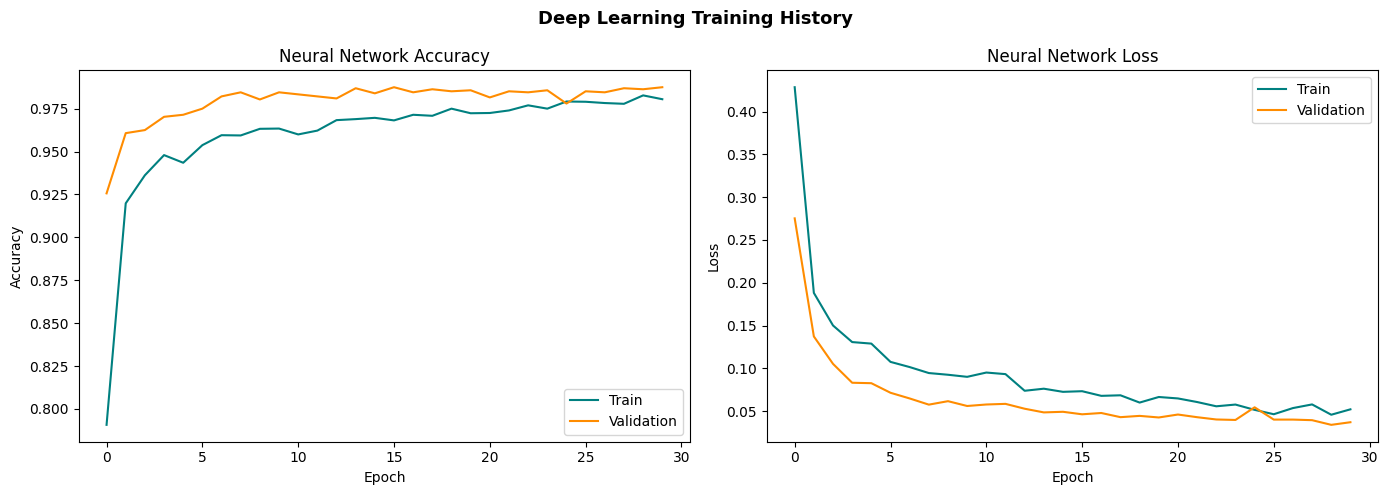

In [32]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train', color='teal')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='darkorange')
axes[0].set_title('Neural Network Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', color='teal')
axes[1].plot(history.history['val_loss'], label='Validation', color='darkorange')
axes[1].set_title('Neural Network Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Deep Learning Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Model Comparison Summary

              Model  Accuracy
Logistic Regression    0.9967
           CatBoost    0.9862
     Neural Network    0.9824
            XGBoost    0.9781
           AdaBoost    0.9776
  Gradient Boosting    0.9757
                SVM    0.9738
      Random Forest    0.9605
      Decision Tree    0.9410
        Naive Bayes    0.9101
                KNN    0.8297


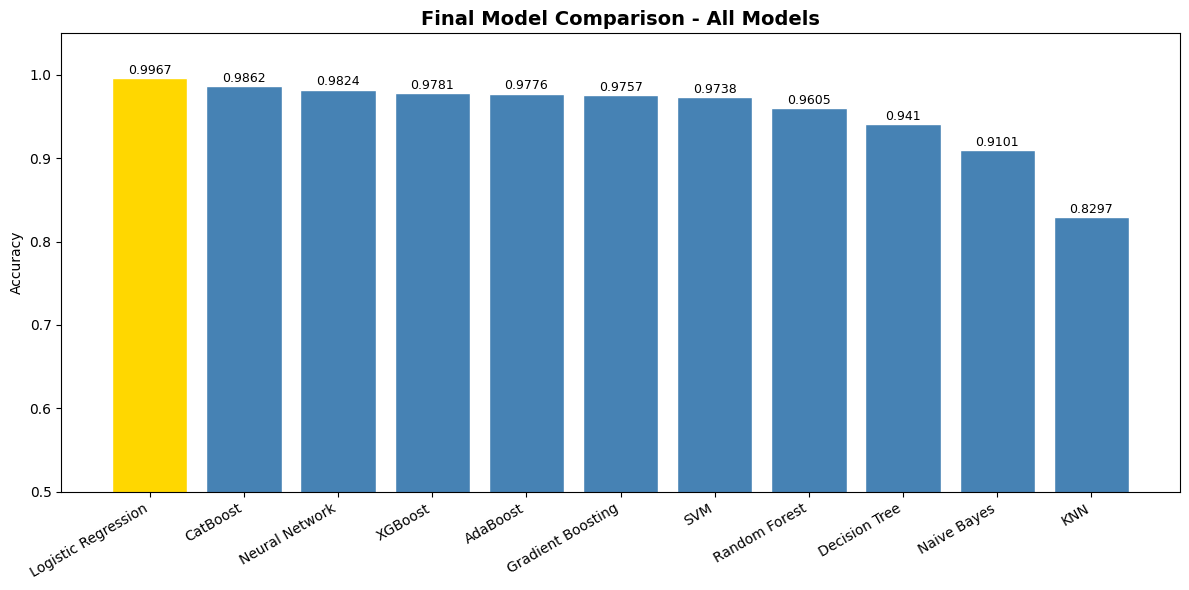


🏆 Best Model: Logistic Regression with 0.9967 accuracy


In [33]:
all_results = {**{k: v for k, v in results.items() if k != 'Linear Regression (MSE)'},
               **ensemble_results,
               'Neural Network': round(acc, 4)}

summary_df = pd.DataFrame(list(all_results.items()), columns=['Model', 'Accuracy'])
summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(summary_df))]
bars = plt.bar(summary_df['Model'], summary_df['Accuracy'], color=colors, edgecolor='white')
plt.ylim(0.5, 1.05)
plt.title('Final Model Comparison - All Models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, summary_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\n🏆 Best Model: {summary_df.iloc[0]["Model"]} with {summary_df.iloc[0]["Accuracy"]} accuracy')